# Workflows

A **workflow** is a directed graph — a small state machine — that turns one
input into one output by walking from a `start` node to an `end` node. It is the
backbone of Kaval.AI, and it exists because agentic pipelines are otherwise very
hard to reason about: every step is named, every edge is explicit, and every
value crossing a node boundary is typed and validated.

You author a workflow two equivalent ways: declaratively in **YAML**, or in
Python with the fluent {class}`~kavalai.WorkflowBuilder`. Both compile to the
same graph and run on the same engine.

| Node | What it does |
|------|--------------|
| `start` / `end` | the boundary — input in, output out |
| `llm` | one structured LLM completion |
| `agent` | a multi-step, tool-using agent loop |
| `function` | a single tool call (`python://`, `rest://`, `mcp://`) |
| `if` / `switch` | branch on a safely-evaluated expression |

This notebook builds those up one node at a time. Every field used here is
listed in the {doc}`../reference/yaml`.

## Setup

Runs are persisted through an {class}`~kavalai.agent_service.AgentService`, which
wraps a sessionmaker pointed at a database. `init_sqlite()` creates the
runtime tables in an in-memory SQLite database, which keeps this notebook
self-contained; in production the same service points at Postgres and nothing
else changes.

Setting `KAVALAI_DEFAULT_LLM_MODEL` means `llm_model` can be left out of every
graph below.

In [1]:
import os
import sys

import dotenv
from loguru import logger

dotenv.load_dotenv("../.env")

os.environ["KAVALAI_DEFAULT_LLM_MODEL"] = "openai/gpt-5.4-mini"
assert os.getenv("OPENAI_API_KEY"), "Set OPENAI_API_KEY to run the LLM nodes."

logger.remove()
_ = logger.add(sys.stderr, level="WARNING")

from kavalai.agent_service import AgentService
from kavalai.db import db_manager
from kavalai.workflow import SqliteTaskLogger, WorkflowEngine

# Create the runtime tables in an in-memory SQLite database.
await db_manager.init_sqlite()


def new_agent_service() -> AgentService:
    """An AgentService over the in-memory SQLite database."""
    return AgentService(db_manager.get_sqlite_sessionmaker())

## 1. The smallest workflow: `start → llm → end`

A graph is `name` + `data_types` + `nodes`. Two conventions make the boundary
ergonomic: the workflow's input is the data type named **`input`**, and what the
caller gets back is the **`output`** variable named on the `end` node.

`data_types` are JSON-schema fragments compiled to Pydantic models, so every
node's input and output is validated. Inside a prompt you interpolate the run
context with `{{ context.<path> }}`.

In [2]:
greeter_yaml = """
name: Village greeter
description: Greets a visitor to Green Village.
data_types:
  input:
    type: object
    properties:
      user_message: {type: string}
  output:
    type: object
    properties:
      agent_response: {type: string}
nodes:
  - {name: start, type: start, next: reply}
  - name: reply
    type: llm
    prompt: |
      You are the warm, concise greeter of Green Village (104 residents, one pub,
      one very old grain tower).
      Reply to the visitor in one friendly sentence: {{ context.input.user_message }}
    inputs:
      input: {type: context, value: input}
    output: output
    next: end
  - {name: end, type: end, output: output}
"""

engine = WorkflowEngine.from_yaml(
    greeter_yaml, agent_service=new_agent_service()
)
state = await engine.run({"user_message": "Hi, I'm visiting from Tallinn!"})

print(state.output_data["agent_response"])
print("path:", " → ".join(state.trace))

Hi there, welcome to Green Village—lovely to meet you, and I hope you enjoy your visit from Tallinn!
path: start → reply → end


## 2. What a run gives you back

`engine.run(...)` returns a {class}`~kavalai.WorkflowState`: the status, the
ordered `trace` of visited nodes, the full context `data`, the `output_data`,
and an aggregate `token_usage`. It round-trips through JSON, and the run is
recorded through the agent service, so it can be reloaded later.

`invocation_id` is worth knowing about: this 8-character id prefixes every log
line the run emits, so you can grep one invocation out of a busy log.

In [3]:
print("status       :", state.status)
print("invocation_id:", state.invocation_id)
print("token_usage  :", state.token_usage)
print()
print("serialised   :", state.to_json()[:160], "…")

status       : completed
invocation_id: 7923120d
token_usage  : {'model_calls': 1, 'prompt_tokens': 106, 'completion_tokens': 36, 'total_tokens': 142}

serialised   : {"workflow_name":"Village greeter","status":"completed","current_node":"end","trace":["start","reply","end"],"data":{"input":{"user_message":"Hi, I'm visiting f …


The conversation was recorded too. A **run** is one invocation; a **session** is
the conversation those runs belong to. Both are rows in your own database: see
{doc}`../guides/data_model` for the `sessions`, `runs` and `chat_messages`
tables.

In [4]:
from uuid import UUID

history = await engine.agent_service.get_chat_history(
    UUID(state.session_id)
)
for message in history:
    print(f"{message.role:>9}: {message.content}")

     user: Hi, I'm visiting from Tallinn!
assistant: Hi there, welcome to Green Village—lovely to meet you, and I hope you enjoy your visit from Tallinn!


The run row itself holds the input, the output and the resolved context — what
each step received:

In [5]:
from kavalai import crud
from kavalai.db import Run

async with engine.agent_service.session_maker() as session:
    run = await crud.get_one(session, Run, UUID(state.run_id))
    print("input_data :", run.input_data)
    print("output_data:", run.output_data)
    print("context    :", sorted(run.context))

input_data : {'user_message': "Hi, I'm visiting from Tallinn!"}
output_data: {'agent_response': 'Hi there, welcome to Green Village—lovely to meet you, and I hope you enjoy your visit from Tallinn!'}
context    : ['input', 'output']


## 3. Function nodes — calling one tool

A `function` node performs exactly one tool call through the
{class}`~kavalai.FunctionKernel`, addressed by URI. Register the tool on the
engine's kernel and name it in the node. The return value lands in the node's
`output` variable and stays in the context for later nodes to read.

Use a function node when you know *which* tool must run. Use an `agent` node
(section 5) when the model should decide.

In [6]:
from pydantic import BaseModel

from kavalai import pythontool


class PondReading(BaseModel):
    depth_m: float
    water: str


@pythontool
def measure_pond(name: str) -> PondReading:
    """Measure a Green Village pond. A real tool would read a sensor."""
    return PondReading(depth_m=1.2, water="murky but calm")


pond_yaml = """
name: Pond reporter
description: >-
  Reads a pond gauge with a function node, then phrases it with an LLM.
data_types:
  input:
    type: object
    properties:
      pond: {type: string}
  reading:
    type: object
    properties:
      depth_m: {type: number}
      water: {type: string}
  output:
    type: object
    properties:
      agent_response: {type: string}
nodes:
  - {name: start, type: start, next: measure}
  - name: measure
    type: function
    tool: python://measure_pond
    inputs:
      name: {type: context, value: input.pond}
    output: reading
    next: phrase
  - name: phrase
    type: llm
    prompt: >-
      Turn this pond reading into one cheerful sentence for the
      village noticeboard.
    inputs:
      reading: {type: context, value: reading}
    output: output
    next: end
  - {name: end, type: end, output: output}
"""

engine = WorkflowEngine.from_yaml(pond_yaml, agent_service=new_agent_service())
engine.kernel.register_python_tool("measure_pond", measure_pond)

state = await engine.run({"pond": "Lake Miller"})
print("tool output in context:", state.data["reading"])
print("final:", state.output_data["agent_response"])

tool output in context: {'depth_m': 1.2, 'water': 'murky but calm'}
final: Lake Miller is a calm, gently murky 1.2-meter-deep pond today—peaceful and perfectly settling in for the village!


## 4. Branching with `if` and `switch`

Routing nodes evaluate an expression against the run context.

- `switch` evaluates `expr`, stringifies the result, and matches it against
  `cases`, falling back to `default`.
- `if` branches on a boolean `condition`.

Below, an `llm` node classifies a message to the Green Village council desk and
a `switch` routes it to a specialised reply. The same graph runs twice and takes
a different path each time.

In [7]:
council_yaml = """
name: Council desk
description: Classifies a message to the village council and routes it.
data_types:
  input:
    type: object
    properties:
      user_message: {type: string}
  classification:
    type: object
    properties:
      intent: {type: string}
  output:
    type: object
    properties:
      agent_response: {type: string}
nodes:
  - {name: start, type: start, next: classify}
  - name: classify
    type: llm
    prompt: |
      Classify the villager's message as exactly one of: repair, permit, other.
      Respond with that single lowercase word in the `intent` field.
    inputs:
      input: {type: context, value: input}
    output: classification
    next: route
  - name: route
    type: switch
    expr: classification.intent
    cases:
      repair: repair_reply
      permit: permit_reply
    default: general_reply
  - name: repair_reply
    type: llm
    prompt: >-
      Acknowledge the repair request and name the next step.
      One short paragraph.
    inputs: {input: {type: context, value: input}}
    output: output
    next: end
  - name: permit_reply
    type: llm
    prompt: >-
      Explain briefly how to apply for this permit in a village of
      104 people.
    inputs: {input: {type: context, value: input}}
    output: output
    next: end
  - name: general_reply
    type: llm
    prompt: "Answer the villager's question helpfully and briefly."
    inputs: {input: {type: context, value: input}}
    output: output
    next: end
  - {name: end, type: end, output: output}
"""

for message in [
    "The church bell has been stuck since Tuesday.",
    "May I put a beehive in my front garden?",
]:
    engine = WorkflowEngine.from_yaml(
        council_yaml, agent_service=new_agent_service()
    )
    state = await engine.run({"user_message": message})
    print(repr(message))
    print("  intent:", state.data["classification"]["intent"])
    print("  path  :", " → ".join(state.trace))
    print("  reply :", state.output_data["agent_response"][:80], "…\n")

'The church bell has been stuck since Tuesday.'
  intent: repair
  path  : start → classify → route → repair_reply → end
  reply : Understood — the church bell has been stuck since Tuesday. Next step: I’ll help  …



'May I put a beehive in my front garden?'
  intent: permit
  path  : start → classify → route → permit_reply → end
  reply : Yes—usually you can, but in a very small village you should check a few local ru …



### Seeing the graph

A workflow is data, so it can be drawn. `render_workflow_svg` turns a
`WorkflowGraph` — or the plain `dict` the backoffice stores for an agent — into
a standalone SVG. Each node is drawn by name and type, and the arrows follow the
transitions; a branch node labels each outgoing arrow with the case that selects
it, so the routing above can be read straight off the picture.

The same renderer serves the SDK, the backoffice `POST /workflows/render-svg`
endpoint and this documentation build, so a diagram never drifts from the
workflow it describes.


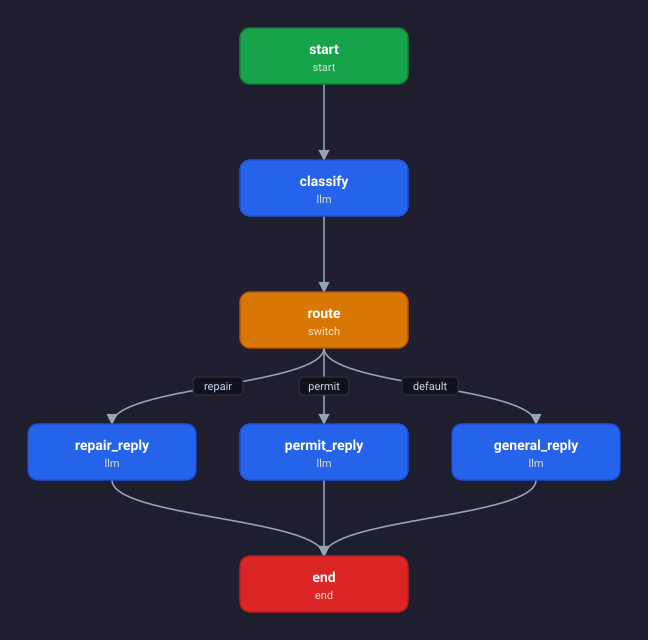

In [ ]:
from IPython.display import SVG, display

from kavalai.workflow import render_workflow_svg

display(SVG(render_workflow_svg(engine.graph)))

### The expression language

Expressions are evaluated **safely** — an AST whitelist, never Python `eval`.
Comparisons, `and` / `or` / `not`, `in`, arithmetic, and dotted or indexed
access into the context are allowed; nothing else is. Unknown names resolve to
`None`, so a guard on a missing value degrades instead of crashing.

The evaluator can be called directly, which is useful when writing a condition:

In [8]:
from kavalai import evaluate_bool, evaluate_expression

ctx = {
    "bell": {"broken_days": 3, "status": "stuck"},
    "ponds": [{"depth_m": 1.2}],
}

print(evaluate_expression(
    "bell.broken_days >= 3 and bell.status == 'stuck'", ctx
))
print(evaluate_expression("ponds[0].depth_m > 0.8", ctx))
print(evaluate_bool("bell.status in ['stuck', 'silent']", ctx))
print(evaluate_expression("missing.value", ctx))  # unknown path -> None

True
True
True
None


## 5. Agent nodes — multi-step tool use

An `agent` node runs the full {class}`~kavalai.Agent` loop inside the graph: it
may call tools repeatedly, feeding results back into its own reasoning, before
emitting its structured output. Give it a kernel of tools and a `max_steps`
budget. `allowed_tools` narrows which of the kernel's tools this node may use.

In [9]:
import datetime


@pythontool
def current_time() -> str:
    """The current UTC time, as a weekday and clock time."""
    return datetime.datetime.now(datetime.timezone.utc).strftime("%A %H:%M UTC")


agent_yaml = """
name: Time-aware greeter
description: An agent that checks the time before greeting the visitor.
data_types:
  input:
    type: object
    properties:
      user_message: {type: string}
  output:
    type: object
    properties:
      agent_response: {type: string}
nodes:
  - {name: start, type: start, next: assistant}
  - name: assistant
    type: agent
    prompt: |
      Greet the visitor to Green Village appropriately for the current time of
      day. Check the time with a tool first; mention it.
    inputs: {input: {type: context, value: input}}
    output: output
    allowed_tools: ["python://current_time"]
    max_steps: 4
    next: end
  - {name: end, type: end, output: output}
"""

engine = WorkflowEngine.from_yaml(agent_yaml, agent_service=new_agent_service())
engine.kernel.register_python_tool("current_time", current_time)

state = await engine.run({"user_message": "Say hello!"})
print(state.output_data["agent_response"])

Good day, and welcome to Green Village! It’s Friday 12:39 UTC right now.


## 6. Watching a run as it happens

`run()` is a convenience wrapper: internally every run is a **stream**.
`run_stream()` yields {class}`~kavalai.workflow.models.WorkflowStreamEvent`
objects as the graph executes, which is what the agent server turns into
Server-Sent Events.

Lifecycle events always arrive; content events (`partial` / `complete`) only
come from nodes that opted in with `stream_output`.

In [10]:
engine = WorkflowEngine.from_yaml(
    council_yaml, agent_service=new_agent_service()
)

report = {"user_message": "The pub sign fell down."}
async for event in engine.run_stream(report):
    detail = ""
    if event.type == "workflow_completed":
        detail = f"  tokens={event.token_usage['total_tokens']}"
    print(f"{event.type:<20} {event.name}{detail}")

workflow_started     Council desk
node_started         start
node_completed       start
node_started         classify


node_completed       classify
node_started         route
node_completed       route
node_started         repair_reply


node_completed       repair_reply
node_started         end
node_completed       end
workflow_completed   Council desk  tokens=235


## 7. Observability — the task logger

A `TaskLogger` captures per-node debug data and every model call. Writes are
fire-and-forget so they never block a run; `get_tasks()` and `get_model_calls()`
await the pending writes before reading, so you do not have to flush by hand.

`SqliteTaskLogger` writes the same `tasks` and `model_call_stats` shape as the
production `PostgresTaskLogger`, so what you inspect locally is what the
backoffice shows in production. Both tables are described column by column in
{doc}`../guides/data_model`.

In [11]:
task_logger = SqliteTaskLogger()
engine = WorkflowEngine.from_yaml(
    council_yaml, agent_service=new_agent_service(), task_logger=task_logger
)
state = await engine.run({"user_message": "How do I book the village hall?"})
await task_logger.flush()  # await the fire-and-forget writes

print("path       :", " → ".join(state.trace))
print("token usage:", state.token_usage)

path       : start → classify → route → permit_reply → end
token usage: {'model_calls': 2, 'prompt_tokens': 181, 'completion_tokens': 118, 'total_tokens': 299}


Every node execution and every LLM call along the way was recorded:

In [12]:
for task in await task_logger.get_tasks():
    print(f"  {task['name']:<14} {task['node_type']:<8} "
          f"{task['duration_seconds']:.2f}s")

calls = await task_logger.get_model_calls()
tokens = sum(call["total_tokens"] or 0 for call in calls)
print(f"\nmodel calls: {len(calls)} · tokens: {tokens}")

  classify       llm      2.58s
  permit_reply   llm      1.70s

model calls: 2 · tokens: 299


In production you point the same engine at Postgres — `AgentService` over a
Postgres sessionmaker and `PostgresTaskLogger` — and browse all of it in the
backoffice UI. See {doc}`observability_storage` and {doc}`../ui/index`.

## 8. Testing a workflow without a model

LLMs are non-deterministic, which makes them poor test fixtures. Inject a
`client_factory` and the engine builds *your* client instead of a real one, so
graph logic — branching, data flow, node wiring — becomes fully deterministic
and free to test.

The engine drives clients through `_run_chat_completions`, pushing values into a
streamer. A stub therefore implements that one method:

In [13]:
from kavalai import BaseLlmClient


class StubClient(BaseLlmClient):
    """Returns canned structured output — no network, fully deterministic."""

    def __init__(self, *args, **kwargs):
        super().__init__()

    async def _run_chat_completions(
        self, chat_history, response_model, streamer
    ):
        value_streamer = streamer.get_value_streamer(
            "response", response_model=response_model
        )
        canned = response_model(
            **{
                name: ("repair" if name == "intent" else "Stubbed reply.")
                for name in response_model.model_fields
            }
        )
        await value_streamer.stream_partial(canned.model_dump_json())
        await value_streamer.stream_complete()


engine = WorkflowEngine.from_yaml(
    council_yaml,
    agent_service=new_agent_service(),
    client_factory=lambda *args, **kwargs: StubClient(),
)
state = await engine.run({"user_message": "anything at all"})

print("deterministic path:", " → ".join(state.trace))
print("reply             :", state.output_data["agent_response"])

deterministic path: start → classify → route → repair_reply → end
reply             : Stubbed reply.


Every run now routes through `repair`, with no network call and no API key. Run
it a hundred times in CI and it behaves identically.

## 9. Building a workflow in code

YAML suits authoring and sharing; the fluent
{class}`~kavalai.WorkflowBuilder` suits a graph that is generated
dynamically, or an agent that belongs in a single Python file. Both produce
the same graph.

Each method returns the builder, so the chain reads like the graph. `data_type`
accepts plain Python types, and an `inputs` value given as a bare string is
treated as a context path. Finish with `.build()` for a graph or
`.build_engine(...)` for a ready engine.

In [14]:
from kavalai import WorkflowBuilder

engine = (
    WorkflowBuilder("Council desk (code)",
                    description="The same graph, built in Python.")
    .data_type("input", {"user_message": str})
    .data_type("classification", {"intent": str})
    .data_type("output", {"agent_response": str})
    .start("classify")
    .llm(
        "classify",
        prompt=(
            "Classify the villager's message as exactly one of: "
            "repair, permit, other. "
            "Respond with that single lowercase word in the `intent` field."
        ),
        inputs={"input": "input"},          # a bare string == a context path
        output="classification",
        next="route",
    )
    .switch(
        "route",
        expr="classification.intent",
        cases={"repair": "repair_reply", "permit": "permit_reply"},
        default="general_reply",
    )
    .llm("repair_reply",
         prompt="Acknowledge the repair request and name the next step.",
         inputs={"input": "input"}, output="output", next="end")
    .llm("permit_reply", prompt="Explain briefly how to apply for this permit.",
         inputs={"input": "input"}, output="output", next="end")
    .llm("general_reply",
         prompt="Answer the villager's question helpfully and briefly.",
         inputs={"input": "input"}, output="output", next="end")
    .end()
    .build_engine(agent_service=new_agent_service())
)

state = await engine.run({"user_message": "The grain tower steps are loose."})
print("path :", " → ".join(state.trace))
print("reply:", state.output_data["agent_response"][:90], "…")

path : start → classify → route → repair_reply → end
reply: Acknowledged. Next step: inspect the grain tower steps to identify which fasteners or supp …


## Recap

- A workflow is a **graph of typed nodes**; callers talk only to the
  `start` / `end` boundary.
- `llm`, `agent` and `function` nodes do the work; `if` / `switch` route on
  safely-evaluated expressions.
- Every run returns a JSON-serialisable {class}`~kavalai.WorkflowState` and is
  persisted through an `AgentService`.
- `run_stream()` is the single execution path; `run()` drains it.
- Inject a `client_factory` for deterministic tests that make no network call.
- Author in **YAML or the `WorkflowBuilder`** — same graph either way.

## Where to next

- {doc}`../reference/yaml` — every node type and field, exhaustively.
- {doc}`../guides/workflows` — the concepts, streaming events and state in depth.
- {doc}`agents` — the tools an `agent` node uses.
- {doc}`observability_storage` — sessions, runs, context and chat history.
- {doc}`serving` — put a workflow behind an HTTP endpoint.

A complete runnable graph lives at
[`examples/support_agent/support_agent.yaml`](https://github.com/Kaval-AI/kaval.ai/blob/main/examples/support_agent/support_agent.yaml).